In [13]:
from dotenv import load_dotenv
import operator
from langchain_groq import ChatGroq
from typing import TypedDict,List,Literal
from pydantic import Field,BaseModel
from langchain_core.messages import AIMessage,SystemMessage,HumanMessage
from langgraph.graph import START,END,StateGraph


In [5]:
load_dotenv()

True

In [7]:
model = ChatGroq( model="llama-3.1-8b-instant",)

## State of Workflow

In [18]:
class State(TypedDict):
    user_msg: str
    topic:str
    needs_classification: bool
    knowledge_level : str

## Schema of understand topic node

In [19]:
class understandtopic(BaseModel):
    topic: str
    knowledge_level : str = Literal["beginner" ,"intermediate","advanced"]
    needs_classification: bool = Field(description= " Tells whether the topic given by the user is clear or not"),Literal[True,False]

## Structured LLM

In [20]:
struc_model= model.with_structured_output(understandtopic)

d:\AI Study Budy\venv\lib\site-packages\pydantic\json_schema.py:2466: PydanticJsonSchemaWarning: Default value typing.Literal['beginner', 'intermediate', 'advanced'] is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)
d:\AI Study Budy\venv\lib\site-packages\pydantic\json_schema.py:2466: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description=' Tells whether the topic given by the user is clear or not'), typing.Literal[True, False]) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


## Understand topic Node

In [21]:
topic_msg = """You are the first node in an AI Study Buddy pipeline.

Your job is to analyze the user's study request and extract structured information from it.

Given the user's message, you must determine:
1. The main topic they want to study (e.g. "Python decorators", "Newton's laws", "LangGraph nodes")
2. Their apparent knowledge level based on how they asked:
   - "beginner" — they used simple language, asked "what is", or seem unfamiliar
   - "intermediate" — they know basics, asking "how does X work" or "difference between"
   - "advanced" — they used technical terms, asking about internals or edge cases
3. Whether the topic is clear enough to proceed or needs clarification:
   - "clear" — you know exactly what to study and can search for it
   - "unclear" — the request is too vague, ambiguous, or missing context"""
def understandtopic_node(state:State)->dict:
    message = state['user_msg']
    output = struc_model.invoke([
        SystemMessage(content=topic_msg),
        HumanMessage(content=message)
    ])

    return {'topic': output.topic,'knowledge_level': output.knowledge_level,'needs_classification': output.needs_classification}

## Router Function

In [27]:
def router(state:State)->Literal['clarify_with_human','search_agent']:
    clearification = state['needs_classification']
    if clearification == True:
        return 'clarify_with_human'
    else:
        return 'search_agent'


## clarify_with_human node

In [28]:
def clarify_with_human():
    return 0

## search_agent

In [29]:
def search_agent():
    return 0

## Creating Graph

In [31]:
graph = StateGraph(State)

## Adding Nodes
graph.add_node('Understand_topic',understandtopic_node)
graph.add_node('clarify_with_human',clarify_with_human)
graph.add_node('search_agent',search_agent)

## Add Edges
graph.add_edge(START,'Understand_topic')
graph.add_conditional_edges('Understand_topic',router)
graph.add_edge('clarify_with_human',END)
graph.add_edge('search_agent',END)

# Graph compilation
workflow = graph.compile()

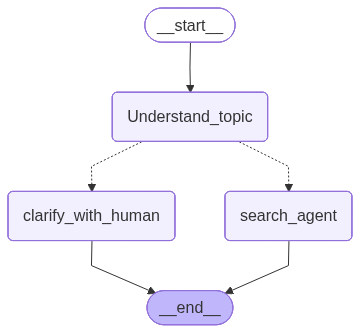

In [32]:
workflow

In [26]:
# Execute the graph
initial_state = {
    'user_msg':'I am learning LAngGraph kya tum mujhy kuch basic concepts de skty ho'

}
workflow.invoke(initial_state)

{'user_msg': 'I am learning LAngGraph kya tum mujhy kuch basic concepts de skty ho',
 'topic': 'LangGraph basic concepts',
 'needs_classification': True,
 'knowledge_level': 'beginner'}